# ***02. Feature Engineering*** 

`EDA(Exploratory Data Analysis) is already finised!`

---
## ***1. Loading Data***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
!pip install category_encoders --quiet
!pip install catboost --quiet

In [2]:
df = pd.read_csv("../data/Car Sell Dataset.csv")
df.head()

,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Year,Kilometers,Owner,State,Accidental,Price
0,Mahindra,TUV300,AX5,SUV,Manual,CNG,2017,164654,1st,Rajasthan,No,547253
1,Skoda,Rapid,Style,Sedan,Manual,Petrol,2018,41351,1st,Maharashtra,No,512050
2,Maruti Suzuki,Alto,Z,Hatchback,Manual,Diesel,2002,119090,3rd+,Tamil Nadu,No,678923
3,Hyundai,Grand i10,Magna,Hatchback,Manual,Diesel,2013,19979,1st,Andhra Pradesh,No,522500
4,Mahindra,XUV500,W8,SUV,Manual,Petrol,2011,130591,3rd+,Bihar,No,401182


---
## ***2. Observations***

### ***For Anomalies***
1. If Accidental = Yes then Price should be low
2. If Car is Luxury then Price should be high
3. If No. of Owners is high then Price should be low
4. If Kilometers is high then Price should be low
5. If a Car is Automatic then Price should be High

---
## ***3. Creating Features***

In [3]:
new_df = df.copy()

In [4]:
from datetime import datetime

current_year = datetime.now().year

new_df["Car_Age"] = current_year - new_df["Year"]

# Average km drives per year of a car
new_df["KM_Per_Year"] = new_df["Kilometers"] / new_df["Car_Age"].replace(0,1)

new_df = new_df.drop(columns=["Year"])
new_df.head()

,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Kilometers,Owner,State,Accidental,Price,Car_Age,KM_Per_Year
0,Mahindra,TUV300,AX5,SUV,Manual,CNG,164654,1st,Rajasthan,No,547253,9,18294.888889
1,Skoda,Rapid,Style,Sedan,Manual,Petrol,41351,1st,Maharashtra,No,512050,8,5168.875000
2,Maruti Suzuki,Alto,Z,Hatchback,Manual,Diesel,119090,3rd+,Tamil Nadu,No,678923,24,4962.083333
3,Hyundai,Grand i10,Magna,Hatchback,Manual,Diesel,19979,1st,Andhra Pradesh,No,522500,13,1536.846154
4,Mahindra,XUV500,W8,SUV,Manual,Petrol,130591,3rd+,Bihar,No,401182,15,8706.066667


In [5]:
new_df.columns

Index(['Brand', 'Model Name', 'Model Variant', 'Car Type', 'Transmission',
       'Fuel Type', 'Kilometers', 'Owner', 'State', 'Accidental', 'Price',
       'Car_Age', 'KM_Per_Year'],
      dtype='object')

In [6]:
price = new_df["Price"]
price

new_df = new_df.drop(columns=["Price"])
new_df["Price"] = price
new_df.head()

,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Kilometers,Owner,State,Accidental,Car_Age,KM_Per_Year,Price
0,Mahindra,TUV300,AX5,SUV,Manual,CNG,164654,1st,Rajasthan,No,9,18294.888889,547253
1,Skoda,Rapid,Style,Sedan,Manual,Petrol,41351,1st,Maharashtra,No,8,5168.875000,512050
2,Maruti Suzuki,Alto,Z,Hatchback,Manual,Diesel,119090,3rd+,Tamil Nadu,No,24,4962.083333,678923
3,Hyundai,Grand i10,Magna,Hatchback,Manual,Diesel,19979,1st,Andhra Pradesh,No,13,1536.846154,522500
4,Mahindra,XUV500,W8,SUV,Manual,Petrol,130591,3rd+,Bihar,No,15,8706.066667,401182


---
## ***3. Features Transformations***

In [7]:
new_df["Owner"].value_counts()

Owner
1st     75429
2nd     56492
3rd+     8983
Name: count, dtype: int64

In [8]:
new_df["Owner"] = new_df["Owner"].map(
    {"1st":1, "2nd":2, "3rd+":3}
)
new_df["Accidental"] = new_df["Accidental"].map(
    {"No": 0, "Yes": 1}
)
new_df["Transmission"] = new_df["Transmission"].map(
    {"Manual": 0, "Automatic": 1}
)

new_df.sample()

,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Kilometers,Owner,State,Accidental,Car_Age,KM_Per_Year,Price
13922,Ford,Aspire,Titanium,Sedan,0,Petrol,17722,1,Rajasthan,0,8,2215.25,442224


In [9]:
X = new_df.drop(columns=["Price"])
y = new_df["Price"]

In [10]:
X.head()

,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Kilometers,Owner,State,Accidental,Car_Age,KM_Per_Year
0,Mahindra,TUV300,AX5,SUV,0,CNG,164654,1,Rajasthan,0,9,18294.888889
1,Skoda,Rapid,Style,Sedan,0,Petrol,41351,1,Maharashtra,0,8,5168.875000
2,Maruti Suzuki,Alto,Z,Hatchback,0,Diesel,119090,3,Tamil Nadu,0,24,4962.083333
3,Hyundai,Grand i10,Magna,Hatchback,0,Diesel,19979,1,Andhra Pradesh,0,13,1536.846154
4,Mahindra,XUV500,W8,SUV,0,Petrol,130591,3,Bihar,0,15,8706.066667


In [11]:
new_df.head()

,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Kilometers,Owner,State,Accidental,Car_Age,KM_Per_Year,Price
0,Mahindra,TUV300,AX5,SUV,0,CNG,164654,1,Rajasthan,0,9,18294.888889,547253
1,Skoda,Rapid,Style,Sedan,0,Petrol,41351,1,Maharashtra,0,8,5168.875000,512050
2,Maruti Suzuki,Alto,Z,Hatchback,0,Diesel,119090,3,Tamil Nadu,0,24,4962.083333,678923
3,Hyundai,Grand i10,Magna,Hatchback,0,Diesel,19979,1,Andhra Pradesh,0,13,1536.846154,522500
4,Mahindra,XUV500,W8,SUV,0,Petrol,130591,3,Bihar,0,15,8706.066667,401182


In [12]:
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        (
            "target",
            TargetEncoder(),
            ["Brand", "Model Name", "Model Variant", "State"]
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore"),
            ["Fuel Type","Car Type"]
        )
    ],
    remainder="passthrough"
)

In [13]:
new_df["Fuel Type"].value_counts()

Fuel Type
Petrol      79187
Diesel      42038
CNG         14054
Electric     2853
Hybrid       2772
Name: count, dtype: int64

In [14]:
new_df["Car Type"].value_counts()

Car Type
Hatchback    55890
Sedan        36897
SUV          35057
MPV           9702
Luxury        3358
Name: count, dtype: int64

In [15]:
new_df["Model Variant"].value_counts()

Model Variant
V            14975
ZX           14896
Base         14199
L            10824
Z            10692
             ...  
R-Dynamic      221
Portfolio      217
LTZ            196
LS             190
LT             169
Name: count, Length: 82, dtype: int64

In [16]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140904 entries, 0 to 140903
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Brand          140904 non-null  object 
 1   Model Name     140904 non-null  object 
 2   Model Variant  140904 non-null  object 
 3   Car Type       140904 non-null  object 
 4   Transmission   140904 non-null  int64  
 5   Fuel Type      140904 non-null  object 
 6   Kilometers     140904 non-null  int64  
 7   Owner          140904 non-null  int64  
 8   State          140904 non-null  object 
 9   Accidental     140904 non-null  int64  
 10  Car_Age        140904 non-null  int64  
 11  KM_Per_Year    140904 non-null  float64
 12  Price          140904 non-null  int64  
dtypes: float64(1), int64(6), object(6)
memory usage: 14.0+ MB


In [17]:
new_df["State"].nunique()

27

In [18]:
new_df["Brand"].nunique()

18

In [19]:
new_df["Model Name"].nunique()

84

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
X_train_processed = preprocessor.fit_transform(X_train, y_train)
feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_train_df["Prices"] = y_train.values
X_test_processed = preprocessor.transform(X_test)
X_train_df.head()

,target__Brand,target__Model Name,target__Model Variant,target__State,onehot__Fuel Type_CNG,onehot__Fuel Type_Diesel,onehot__Fuel Type_Electric,onehot__Fuel Type_Hybrid,onehot__Fuel Type_Petrol,onehot__Car Type_Hatchback,...,onehot__Car Type_MPV,onehot__Car Type_SUV,onehot__Car Type_Sedan,remainder__Transmission,remainder__Kilometers,remainder__Owner,remainder__Accidental,remainder__Car_Age,remainder__KM_Per_Year,Prices
0,746559.975677,624623.194860,733484.458151,786930.123503,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,119069.0,1.0,0.0,6.0,19844.833333,1320000
1,764426.487317,864829.590944,733484.458151,670949.572193,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,22268.0,1.0,0.0,4.0,5567.000000,1396500
2,746559.975677,749463.083454,704796.919178,790990.695046,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,145608.0,1.0,0.0,9.0,16178.666667,554400
3,689419.054739,725301.899630,721717.007884,673301.610401,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,112145.0,2.0,0.0,13.0,8626.538462,432441
4,746559.975677,627695.876446,786981.316272,790990.695046,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,129376.0,2.0,0.0,15.0,8625.066667,431244


In [22]:
X_train_df.to_csv("../data/processed_train_data.csv")

---
## ***4. Baseline Modeling***

### ***4.1 Xgboost***

In [23]:
!pip install xgboost

In [24]:
import xgboost as xgb

In [25]:
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

In [26]:
base_xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor())
])

xgb_model = base_xgb_model.named_steps["regressor"]
base_xgb_model.fit(X_train, y_train)
y_base_xgb_pred = base_xgb_model.predict(X_test)

print(r2_score(y_test, y_base_xgb_pred))

0.3151611089706421


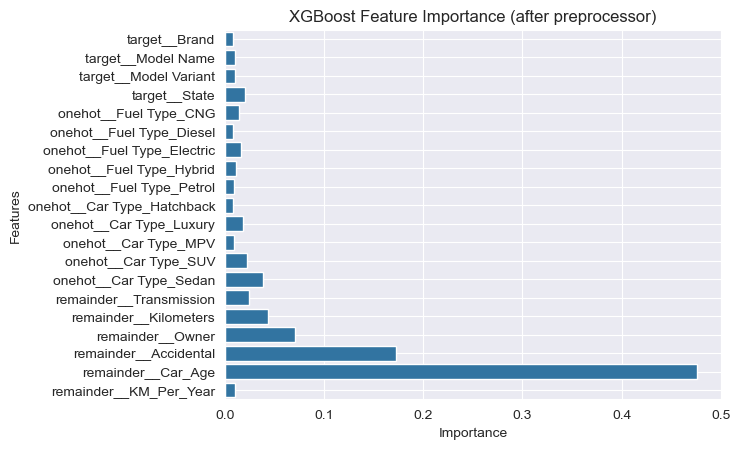

In [27]:
xgb_importances = xgb_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()

sns.set_style("dark")
sns.barplot(x=xgb_importances, y=feature_names)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance (after preprocessor)")
plt.grid(True)
plt.savefig("../plots/xgboost_feature_importance.png")
plt.show()

### ***4.2 Catboost***

In [28]:
base_catboost_model = Pipeline([
     ("preprocessor", preprocessor),
     ("regressor", CatBoostRegressor())
])

catboost_model = base_catboost_model.named_steps["regressor"]
base_catboost_model.fit(X_train, y_train)
y_base_catboost_pred = base_catboost_model.predict(X_test)

print(r2_score(y_test, y_base_catboost_pred))

Learning rate set to 0.086377
0:	learn: 432785.1310435	total: 159ms	remaining: 2m 39s
1:	learn: 422981.4656552	total: 179ms	remaining: 1m 29s
2:	learn: 414602.6736376	total: 197ms	remaining: 1m 5s
3:	learn: 407395.0054233	total: 215ms	remaining: 53.5s
4:	learn: 401195.7951652	total: 234ms	remaining: 46.5s
5:	learn: 396024.1432867	total: 252ms	remaining: 41.7s
6:	learn: 391462.8931886	total: 271ms	remaining: 38.4s
7:	learn: 387622.1363815	total: 289ms	remaining: 35.9s
8:	learn: 384363.9229220	total: 308ms	remaining: 33.9s
9:	learn: 381559.3687782	total: 328ms	remaining: 32.5s
10:	learn: 379230.2394875	total: 348ms	remaining: 31.3s
11:	learn: 377346.5025041	total: 365ms	remaining: 30s
12:	learn: 375587.7927349	total: 385ms	remaining: 29.2s
13:	learn: 374124.0408248	total: 403ms	remaining: 28.4s
14:	learn: 372848.9211737	total: 421ms	remaining: 27.6s
15:	learn: 371739.0792184	total: 439ms	remaining: 27s
16:	learn: 370753.5509477	total: 457ms	remaining: 26.4s
17:	learn: 369896.3374365	tota

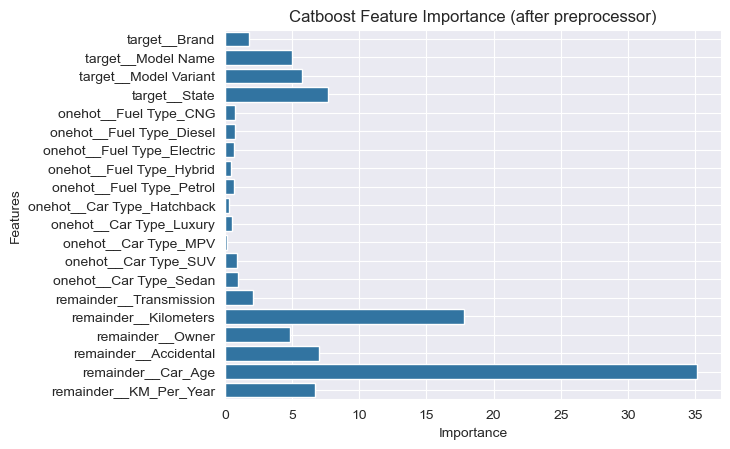

In [29]:
catboost_importances = catboost_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()

sns.set_style("dark")
sns.barplot(x=catboost_importances, y=feature_names)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Catboost Feature Importance (after preprocessor)")
plt.grid(True)
plt.savefig("../plots/catboost_feature_importance.png")
plt.show()

## ***5. Scaling Features***

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

In [31]:
X_train_scaled.shape

(112723, 20)

In [32]:
X_test_scaled.shape

(28181, 20)

In [33]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=feature_names
)
X_train_scaled["Price"] = y_train.values

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=feature_names
)
X_test_scaled["Price"] = y_test.values

In [34]:
X_train_scaled.head()

,target__Brand,target__Model Name,target__Model Variant,target__State,onehot__Fuel Type_CNG,onehot__Fuel Type_Diesel,onehot__Fuel Type_Electric,onehot__Fuel Type_Hybrid,onehot__Fuel Type_Petrol,onehot__Car Type_Hatchback,...,onehot__Car Type_MPV,onehot__Car Type_SUV,onehot__Car Type_Sedan,remainder__Transmission,remainder__Kilometers,remainder__Owner,remainder__Accidental,remainder__Car_Age,remainder__KM_Per_Year,Price
0,-0.227056,-0.989260,-0.415871,0.517826,-0.332852,1.534845,-0.144515,-0.140529,-1.133757,1.231772,...,-0.271865,-0.575537,-0.594758,-0.418703,0.485928,-0.860915,-0.294211,-0.594113,0.478381,1320000
1,0.034291,0.739447,-0.415871,-1.899188,-0.332852,1.534845,-0.144515,-0.140529,-1.133757,-0.811839,...,-0.271865,1.737507,-0.594758,-0.418703,-1.484115,-0.860915,-0.294211,-0.985815,-0.758094,1396500
2,-0.227056,-0.090817,-0.833047,0.602447,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,-0.811839,...,3.678302,-0.575537,-0.594758,-0.418703,1.026036,-0.860915,-0.294211,-0.006561,0.160887,554400
3,-1.062900,-0.264700,-0.586994,-1.850171,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,-0.811839,...,-0.271865,-0.575537,1.681356,2.388329,0.345015,0.768996,-0.294211,0.776843,-0.493135,432441
4,-0.227056,-0.967146,0.362084,0.602447,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,1.231772,...,-0.271865,-0.575537,-0.594758,-0.418703,0.695691,0.768996,-0.294211,1.168545,-0.493263,431244


In [35]:
X_test_scaled.head()

,target__Brand,target__Model Name,target__Model Variant,target__State,onehot__Fuel Type_CNG,onehot__Fuel Type_Diesel,onehot__Fuel Type_Electric,onehot__Fuel Type_Hybrid,onehot__Fuel Type_Petrol,onehot__Car Type_Hatchback,...,onehot__Car Type_MPV,onehot__Car Type_SUV,onehot__Car Type_Sedan,remainder__Transmission,remainder__Kilometers,remainder__Owner,remainder__Accidental,remainder__Car_Age,remainder__KM_Per_Year,Price
0,-0.227056,-0.989260,-0.833047,-1.893143,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,1.231772,...,-0.271865,-0.575537,-0.594758,-0.418703,1.525115,-0.860915,-0.294211,-0.789964,1.706501,889200
1,-1.062900,-0.860929,-1.297926,-1.893143,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,-0.811839,...,-0.271865,-0.575537,1.681356,-0.418703,-0.377748,0.768996,-0.294211,0.972694,-0.766179,114007
2,-0.227056,-0.989260,-0.489832,0.610638,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,1.231772,...,-0.271865,-0.575537,-0.594758,-0.418703,-1.632376,0.768996,-0.294211,1.560247,-1.163876,745360
3,-0.903191,-0.854251,-0.954798,0.498822,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,-0.811839,...,-0.271865,1.737507,-0.594758,-0.418703,-0.831484,0.768996,-0.294211,1.560247,-0.963405,389077
4,-1.062900,0.845617,-0.574081,0.602447,-0.332852,-0.651531,-0.144515,-0.140529,0.882023,-0.811839,...,-0.271865,1.737507,-0.594758,2.388329,0.138874,0.768996,-0.294211,-0.398262,0.021896,645668


In [36]:
X_train_scaled.to_csv("../data/scaled_train_data.csv")
X_test_scaled.to_csv("../data/scaled_test_data.csv")

---
## ***6. Conclusion***

1. Feature engineering for used car fraud detection revealed a critical data leakage trap: derived temporal features like Car_Age and Km_per_year pushed tree models to R² = 0.99 by allowing them to trivially reconstruct price from year alone. After removing redundant derivations and replacing them with semantically meaningful signals — brand-state target encodings, ownership sequences, and mileage-adjusted depreciation features the model generalised to a more honest R² that reflects actual market learning rather than arithmetic shortcuts. The most valuable features across both XGBoost and CatBoost consistently proved to be `car_year`, `km`, and `state` — confirming that temporal depreciation and regional market variation are the primary price drivers in India's used car market. These engineered features now form the input foundation for the downstream anomaly detection pipeline, where the price residual from this model becomes the strongest fraud signal.

2. The R² of 0.27 reflects an inherent information ceiling in this dataset: the Model Variant column is a coarse trim tier rather than the full variant name, which is the primary driver of used car pricing. Despite this, the model generates price residuals that are informative enough for anomaly detection, `Our goal is not to predict price precisely but to flag statistical deviations.`